**Farah Khairunnisa Prakasa**

# Churn Analysis (Data Science Project)

# Import Libraries

In [ ]:
# Standard libraries for data analysis:
import numpy as np
import pandas as pd
pd.options.display.max_columns = None
from pandas.plotting import scatter_matrix
from scipy.stats import norm, skew

# sklearn modules for data preprocessing
from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
)
from sklearn.model_selection import train_test_split

# sklearn modules for Model Selection
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


# sklearn modules for Model Evaluation & Improvement
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    fbeta_score
)

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import (
    cross_val_score,
    GridSearchCV,
    ShuffleSplit,
    KFold
)

# Standard libraries for data visualization
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns
%matplotlib inline
color = sns.color_palette()
import matplotlib.ticker as mtick
from IPython.display import display

# Miscellaneous Utilitiy Libraries
import random
from datetime import datetime
import string

# Import Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import the dataset
file_dir = "/content/drive/MyDrive/Bootcamp Data Science/customer_churn_data1.csv"
dataset = pd.read_csv(file_dir)

# Read Dataset
display(dataset)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
dataset.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
dataset.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
dataset.duplicated().sum()

np.int64(0)

In [ ]:
dataset['TotalCharges'] = pd.to_numeric(dataset['TotalCharges'], errors='coerce')

dataset['TotalCharges'] = dataset['TotalCharges'].astype("float")

"TotalCharges" seharusnya adalah float, bukan object/kategorikal

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
dataset[dataset["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [ ]:
dataset['TotalCharges'] = dataset['TotalCharges'].fillna((dataset['MonthlyCharges']*dataset['tenure']))

In [ ]:
dataset["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [ ]:
dataset["Churn"].value_counts(normalize=True)

,proportion
Churn,
No,0.73463
Yes,0.26537


In [ ]:
dataset_new = pd.get_dummies(dataset, columns=["gender",
                                               "Partner",
                                               "Dependents",
                                               "PhoneService",
                                               "MultipleLines",
                                               "InternetService",
                                               "OnlineSecurity",
                                               "OnlineBackup",
                                               "DeviceProtection",
                                               "TechSupport",
                                               "StreamingTV",
                                               "StreamingMovies",
                                               "Contract",
                                               "PaperlessBilling",
                                               "PaymentMethod"],
                             dtype=int)

# EDA

In [ ]:
dataset.groupby("Churn")["tenure"].mean()

,tenure
Churn,
No,37.569965
Yes,17.979133


In [ ]:
dataset.groupby(["SeniorCitizen"])["customerID"].count().reset_index()

,SeniorCitizen,customerID
0,0,5901
1,1,1142


In [ ]:
dataset.groupby(["Dependents"])["customerID"].count().reset_index()

,Dependents,customerID
0,No,4933
1,Yes,2110


In [ ]:
dataset.groupby("Contract")["Contract"].value_counts()

,count
Contract,
Month-to-month,3875
One year,1473
Two year,1695


In [ ]:
dataset.groupby("PaymentMethod")["PaymentMethod"].value_counts()

,count
PaymentMethod,
Bank transfer (automatic),1544
Credit card (automatic),1522
Electronic check,2365
Mailed check,1612


In [ ]:
# Distribusi Biaya Bulanan = Total Charges
dataset[['Churn','Contract']].value_counts()

Churn  Contract      
No     Month-to-month    2220
Yes    Month-to-month    1655
No     Two year          1647
       One year          1307
Yes    One year           166
       Two year            48
Name: count, dtype: int64

In [ ]:
dataset[['Churn', 'MonthlyCharges']].groupby(['Churn'], as_index=False).mean()

,Churn,MonthlyCharges
0,No,61.265124
1,Yes,74.441332


In [ ]:
dataset[['Churn', 'TotalCharges']].groupby(['Churn'], as_index=False).mean()

,Churn,TotalCharges
0,No,2549.911442
1,Yes,1531.796094


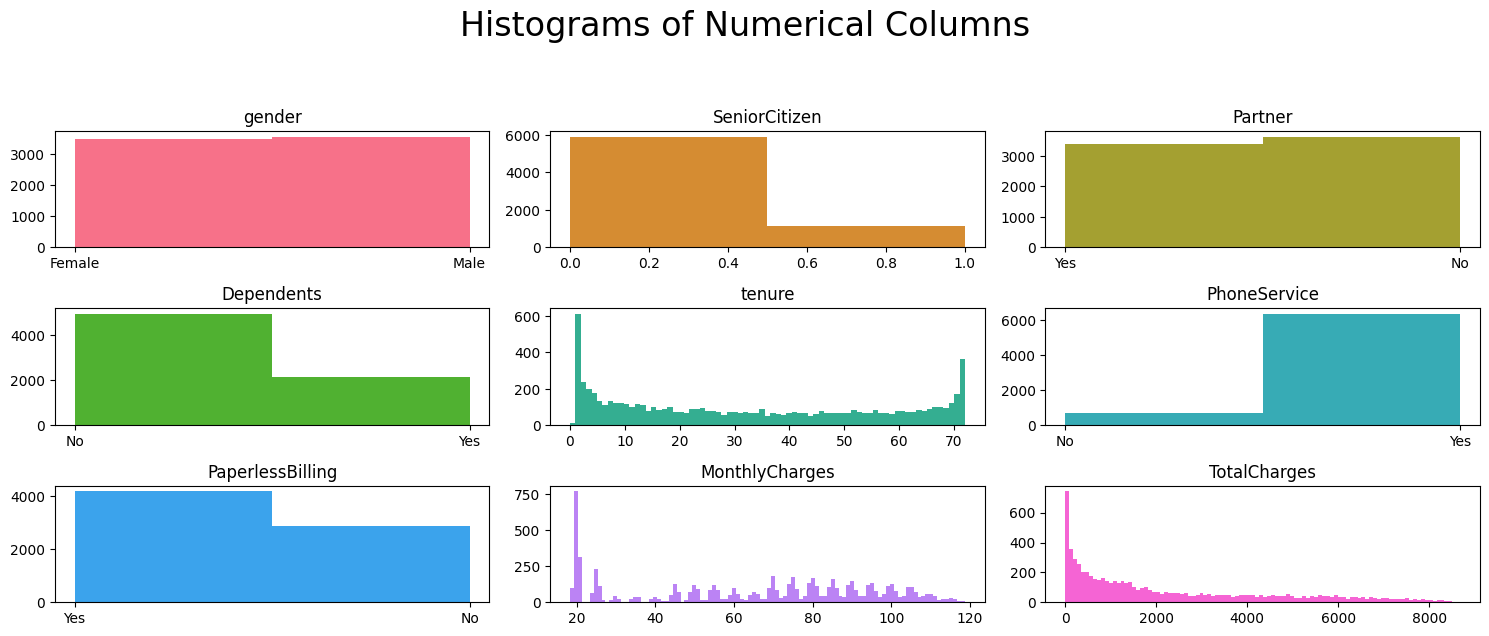

In [ ]:
# Exploratory Data Analysis

# Plot Histogram of numeric columns
num_cols = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'tenure',
    'PhoneService',
    'PaperlessBilling',
    'MonthlyCharges',
    'TotalCharges'
]

dataset2 = dataset[num_cols]

# Define a color palette with distinct colors
palette = sns.color_palette("husl", len(num_cols))

# Histogram:
fig = plt.figure(figsize=(15, 12))
plt.suptitle(
    'Histograms of Numerical Columns',
    horizontalalignment="center",
    fontstyle="normal",
    fontsize=24,
    fontfamily="sans-serif"
)

for i in range(dataset2.shape[1]):
    plt.subplot(6, 3, i + 1 )
    f = plt.gca()
    f.set_title(dataset2.columns.values[i])

    vals = np.size(dataset2.iloc[:, i].unique())
    if vals >= 100:
        vals = 100

    # Use the color palette for each subplot
    plt.hist(
        dataset2.iloc[:, i],
        bins=vals,
        color=palette[i]
    )

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
dataset['gender'].value_counts(normalize=True)

,proportion
gender,
Male,0.504756
Female,0.495244


In [ ]:
dataset['SeniorCitizen'].value_counts(normalize=True)

,proportion
SeniorCitizen,
0,0.837853
1,0.162147


1. Mayoritas pelanggan bukan senior dan tidak memiliki tanggungan.
2. Banyak pelanggan dengan tenure rendah, yang bisa terkait dengan churn.
3. Sebagian besar pelanggan menggunakan layanan telepon dan lebih memilih paperless billing.
4. Distribusi biaya bulanan bervariasi, tetapi banyak pelanggan berada di kisaran rendah hingga menengah.
5. Total biaya berlangganan meningkat seiring waktu, dengan lonjakan pelanggan baru.

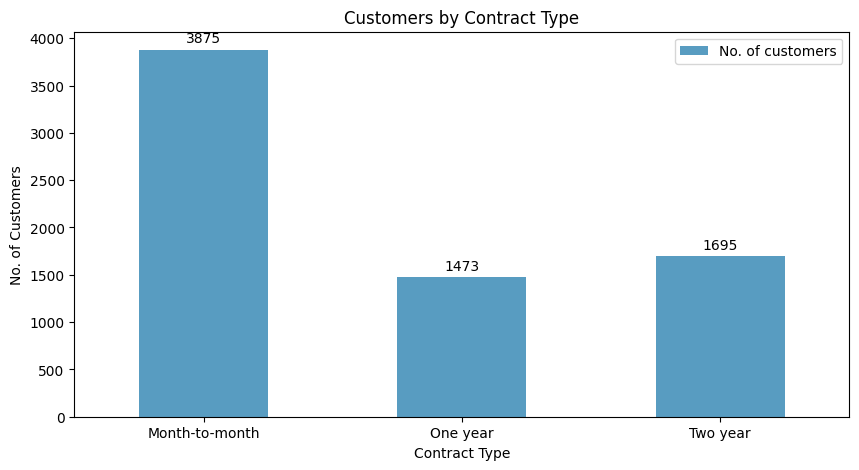

In [ ]:
# Distribution of Contract Type
contract_split = dataset[[ "customerID", "Contract"]]
sectors = contract_split.groupby ("Contract")
contract_split = pd.DataFrame(sectors["customerID"].count())
contract_split.rename(
    columns={'customerID':'No. of customers'},
    inplace=True
)

ax = contract_split[["No. of customers"]].plot.bar(
    title='Customers by Contract Type',
    legend=True,
    table=False,
    grid=False,
    subplots=False,
    figsize=(10, 5),
    color='#589cc1',
    stacked=False
)

plt.ylabel(
    'No. of Customers',
    horizontalalignment="center",
    fontstyle="normal",
    fontfamily="sans-serif"
)
plt.xlabel(
    'Contract Type',
    horizontalalignment="center",
    fontstyle="normal",
    fontfamily="sans-serif"
)
plt.title(
    'Customers by Contract Type',
    horizontalalignment="center",
    fontstyle="normal",
    fontfamily="sans-serif"
)

plt.legend(loc='upper right')
plt.xticks(rotation=0, horizontalalignment="center")
plt.yticks(rotation=0, horizontalalignment="right")

x_labels = np.array(contract_split[["No. of customers"]])

def add_value_labels(ax, spacing=3):
    for rect in ax.patches:
        y_value = rect.get_height()
        x_value = rect.get_x() + rect.get_width() / 2
        space = spacing
        va = 'bottom'
        if y_value < 0:
            space *= -1
            va = 'top'
        label = "{:.0f}".format(y_value)
        ax.annotate(
            label,
            (x_value, y_value),
            xytext=(0, space),
            textcoords="offset points",
            ha='center',
            va=va)

add_value_labels(ax)

1. Mayoritas pelanggan menggunakan kontrak bulanan (Month-to-month) dengan jumlah 3,875 pelanggan.
2. Pelanggan dengan kontrak satu tahun jauh lebih sedikit (1,473 pelanggan).
3. Pelanggan dengan kontrak dua tahun sedikit lebih banyak dibandingkan satu tahun, tetapi masih jauh lebih sedikit dibandingkan kontrak bulanan (1,695 pelanggan).




Perusahaan mungkin perlu mendorong lebih banyak pelanggan untuk memilih kontrak jangka panjang guna mengurangi churn.

Analisis churn berdasarkan jenis kontrak bisa dilakukan untuk melihat apakah pelanggan kontrak bulanan memiliki tingkat churn lebih tinggi dibandingkan pelanggan kontrak satu atau dua tahun.

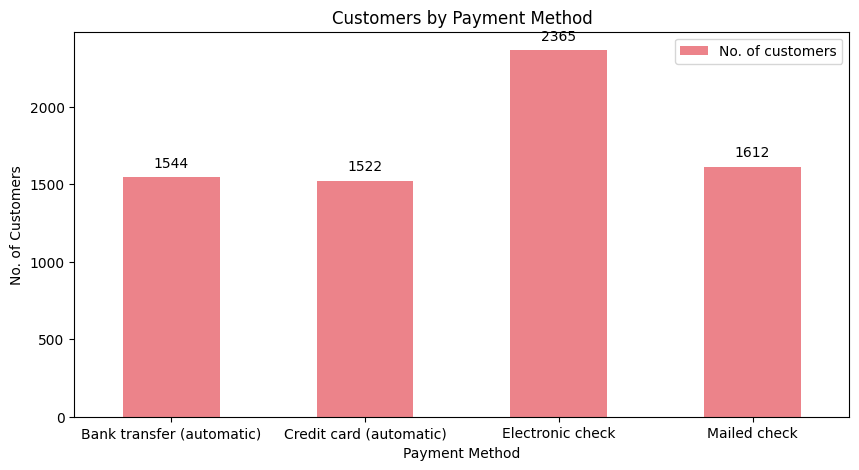

In [ ]:
# Distribution of Payment Method Type

payment_method_split = dataset[[ "customerID", "PaymentMethod"]]
sectors = payment_method_split.groupby ("PaymentMethod")
payment_method_split = pd.DataFrame(sectors["customerID"].count())
payment_method_split.rename(
    columns={'customerID':'No. of customers'},
    inplace=True
)

ax = payment_method_split[["No. of customers"]].plot.bar(
    title='Customers by Payment Method',
    legend=True,
    table=False,
    grid=False,
    subplots=False,
    figsize=(10, 5),
    color='#ec838a',
    stacked=False
)

plt.ylabel(
    'No. of Customers',
    horizontalalignment="center",
    fontstyle="normal",
    fontfamily="sans-serif"
)
plt.xlabel(
    'Payment Method',
    horizontalalignment="center",
    fontstyle="normal",
    fontfamily="sans-serif"
)
plt.title(
    'Customers by Payment Method',
    horizontalalignment="center",
    fontstyle="normal",
    fontfamily="sans-serif"
)
plt.legend(loc='upper right')
plt.xticks(rotation=0, horizontalalignment="center")
plt.yticks(rotation=0, horizontalalignment="right")

x_labels = np.array(payment_method_split[["No. of customers"]])

def add_value_labels(ax, spacing=5):
    for rect in ax.patches:
        y_value = rect.get_height()
        x_value = rect.get_x() + rect.get_width() / 2
        space = spacing
        va = 'bottom'
        if y_value < 0:
            space *= -1
            va = 'top'
        label = "{:.0f}".format(y_value)
        ax.annotate(
            label,
            (x_value, y_value),
            xytext=(0, space),
            textcoords="offset points",
            ha='center',
            va=va)

add_value_labels(ax)

1. Metode pembayaran yang paling banyak digunakan adalah "Electronic check", dengan 2,365 pelanggan.
2. Metode pembayaran otomatis seperti "Bank transfer (1,544 pelanggan)" dan "Credit card (1,522 pelanggan)" memiliki jumlah yang lebih rendah dibandingkan electronic check.
3. "Mailed check" digunakan oleh 1,612 pelanggan, sedikit lebih tinggi dibandingkan transfer bank dan kartu kredit otomatis.

Pelanggan yang menggunakan "Electronic check" mungkin memiliki tingkat churn lebih tinggi, karena pembayaran manual bisa lebih mudah dihentikan.

Perusahaan bisa mendorong pelanggan untuk beralih ke metode pembayaran otomatis guna meningkatkan retensi dan mengurangi churn.

Perlu dilakukan analisis lebih lanjut terkait hubungan antara metode pembayaran dan churn rate untuk memastikan apakah ada korelasi yang signifikan.

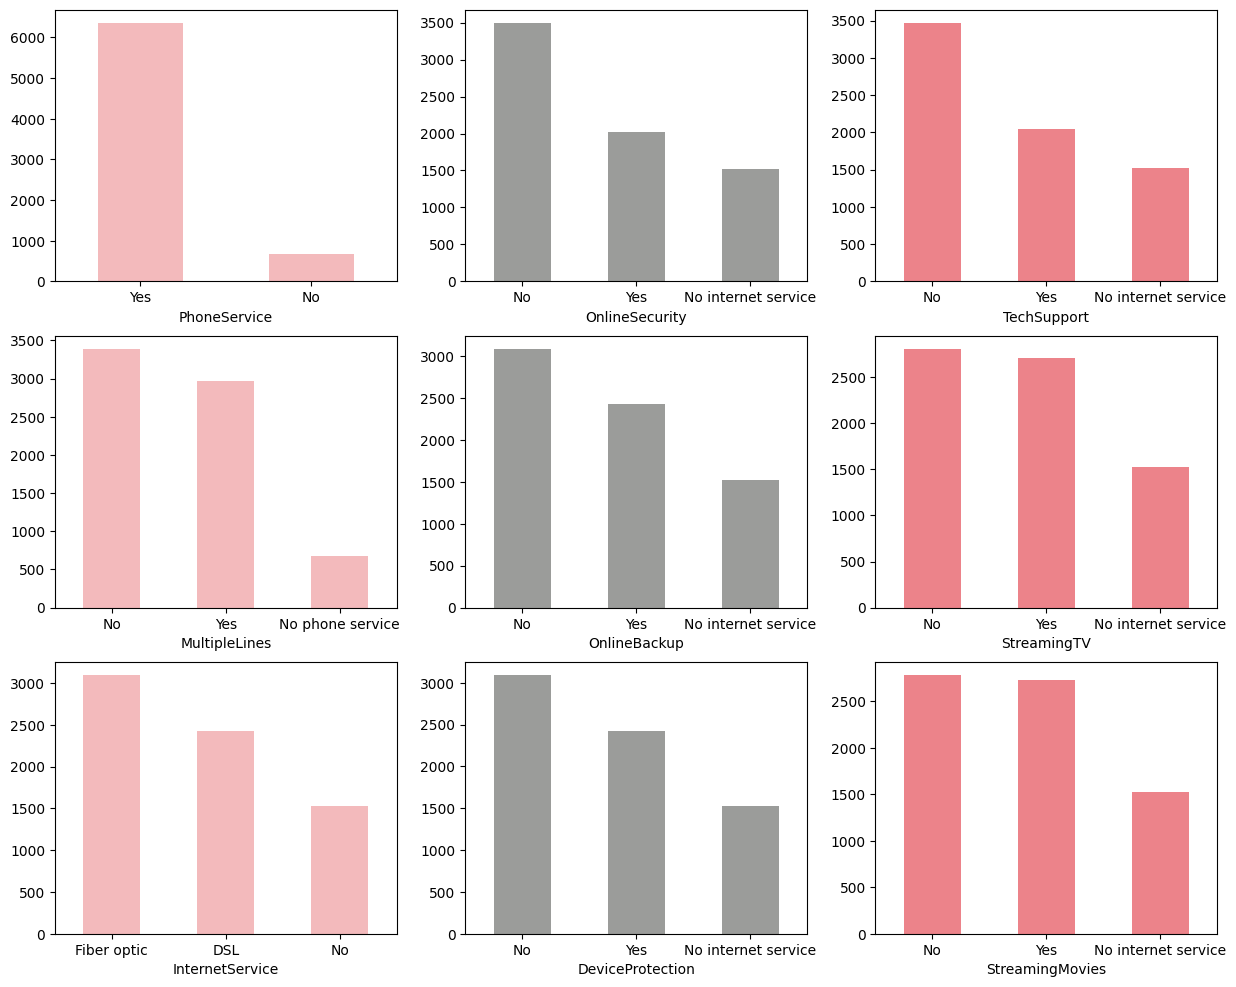

In [ ]:
# Distribution of various Label Encoded Categorical Variables

services = [
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

fig, axes = plt.subplots(
    nrows=3, ncols=3, figsize=(15,12)
)

for i, item in enumerate(services):
    if i < 3:
        ax = dataset[item].value_counts().plot(
            kind='bar', ax=axes[i, 0],
            rot=0, color='#f3babc'
        )

    elif i >= 3 and i < 6:
        ax = dataset[item].value_counts().plot(
            kind='bar', ax=axes[i-3, 1],
            rot=0, color ='#9b9c9a'
        )

    elif i < 9:
        ax = dataset[item].value_counts().plot(
            kind='bar', ax=axes[i-6, 2],
            rot=0, color='#ec838a'
        )



1. Mayoritas pelanggan menggunakan layanan telepon (PhoneService).

Visualisasi menunjukkan jumlah pelanggan dengan PhoneService = Yes jauh lebih besar dibanding No. Ini berarti layanan telepon merupakan layanan dasar yang hampir digunakan oleh seluruh pelanggan. Karena distribusinya sangat tidak seimbang, variabel ini kemungkinan kurang kuat untuk membedakan pelanggan churn dan non-churn secara langsung, tetapi tetap penting sebagai baseline layanan utama.

2. Fitur keamanan dan dukungan internet belum banyak digunakan.

Pada variabel OnlineSecurity, TechSupport, OnlineBackup, dan DeviceProtection, kategori No selalu lebih tinggi dibanding Yes. Ini menunjukkan banyak pelanggan internet belum mengambil layanan tambahan seperti keamanan online, backup, atau proteksi perangkat. Dari sudut bisnis, ini bisa menjadi peluang upselling. Dari sisi analisis churn, pelanggan tanpa layanan tambahan sering kali lebih rentan churn karena keterikatan mereka terhadap layanan perusahaan lebih rendah.

3. Pelanggan internet fiber optic mendominasi.

Pada InternetService, pengguna Fiber optic paling banyak dibanding DSL maupun pelanggan tanpa internet. Ini mengindikasikan bahwa mayoritas pelanggan memilih koneksi dengan kecepatan lebih tinggi. Namun, dalam banyak kasus dataset churn telecom, pelanggan fiber optic juga sering memiliki tingkat churn lebih tinggi karena ekspektasi layanan mereka lebih besar (misalnya terkait harga atau kualitas koneksi). Ini menjadi variabel penting untuk dianalisis lebih lanjut terhadap churn.

4. Layanan hiburan digital memiliki penggunaan yang relatif seimbang.

Pada StreamingTV dan StreamingMovies, jumlah pengguna Yes dan No terlihat cukup mirip. Artinya layanan streaming cukup populer dan tidak terlalu timpang distribusinya. Variabel dengan distribusi seperti ini biasanya lebih informatif untuk machine learning karena mampu membedakan karakteristik pelanggan dengan lebih baik dibanding variabel yang sangat dominan pada satu kategori saja.


# Modelling

In [ ]:
X = dataset_new.drop(['customerID', 'Churn'], axis=1)
y = dataset_new['Churn'].map({'No': 0, 'Yes': 1})

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Scalling Data
# Train
sc_X = StandardScaler()
X_tr_columns = X_train.columns
X_tr_idx = X_train.index
X_train = pd.DataFrame(
    sc_X.fit_transform(X_train),
    columns=X_tr_columns,
    index=X_tr_idx
)
# Test
X_ts_columns = X_test.columns
X_ts_idx = X_test.index
X_test = pd.DataFrame(
    sc_X.transform(X_test),
    columns=X_ts_columns,
    index=X_ts_idx
)

In [ ]:
X_train

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,PhoneService_Yes,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,-0.441773,0.102371,-0.521976,-0.262257,-0.994336,0.994336,0.969234,-0.969234,0.651557,-0.651557,3.013090,-3.013090,-0.95419,3.013090,-0.858338,1.381529,-0.887696,-0.524081,1.007125,-0.524081,-0.636111,1.143296,-0.524081,-0.735546,-0.884185,-0.524081,1.375572,1.016465,-0.524081,-0.643274,-0.808189,-0.524081,1.252163,-0.80549,-0.524081,1.247967,0.903464,-0.512782,-0.563822,1.202653,-1.202653,-0.532326,-0.523806,1.406903,-0.543846
3151,-0.441773,-0.711743,0.337478,-0.503635,-0.994336,0.994336,-1.031742,1.031742,-1.534786,1.534786,-0.331885,0.331885,1.04801,-0.331885,-0.858338,-0.723836,1.126512,-0.524081,-0.992925,-0.524081,1.572053,1.143296,-0.524081,-0.735546,1.130985,-0.524081,-0.726971,1.016465,-0.524081,-0.643274,1.237335,-0.524081,-0.798618,1.24148,-0.524081,-0.801303,0.903464,-0.512782,-0.563822,1.202653,-1.202653,-0.532326,-0.523806,-0.710781,1.838757
4860,-0.441773,-0.793155,-0.809013,-0.749883,-0.994336,0.994336,-1.031742,1.031742,-1.534786,1.534786,3.013090,-3.013090,-0.95419,3.013090,-0.858338,1.381529,-0.887696,-0.524081,-0.992925,-0.524081,1.572053,-0.874664,-0.524081,1.359534,1.130985,-0.524081,-0.726971,-0.983802,-0.524081,1.554547,1.237335,-0.524081,-0.798618,1.24148,-0.524081,-0.801303,-1.106851,-0.512782,1.773611,1.202653,-1.202653,-0.532326,-0.523806,-0.710781,1.838757
3867,-0.441773,-0.263980,0.284384,-0.172722,1.005696,-1.005696,-1.031742,1.031742,0.651557,-0.651557,-0.331885,0.331885,1.04801,-0.331885,-0.858338,1.381529,-0.887696,-0.524081,1.007125,-0.524081,-0.636111,-0.874664,-0.524081,1.359534,-0.884185,-0.524081,1.375572,1.016465,-0.524081,-0.643274,-0.808189,-0.524081,1.252163,-0.80549,-0.524081,1.247967,-1.106851,-0.512782,1.773611,-0.831495,0.831495,-0.532326,1.909105,-0.710781,-0.543846
3810,-0.441773,-1.281624,-0.676279,-0.989374,-0.994336,0.994336,-1.031742,1.031742,-1.534786,1.534786,-0.331885,0.331885,1.04801,-0.331885,-0.858338,1.381529,-0.887696,-0.524081,1.007125,-0.524081,-0.636111,1.143296,-0.524081,-0.735546,1.130985,-0.524081,-0.726971,1.016465,-0.524081,-0.643274,1.237335,-0.524081,-0.798618,1.24148,-0.524081,-0.801303,0.903464,-0.512782,-0.563822,1.202653,-1.202653,-0.532326,-0.523806,1.406903,-0.543846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6303,-0.441773,1.567778,1.470695,2.373129,1.005696,-1.005696,-1.031742,1.031742,0.651557,-0.651557,-0.331885,0.331885,-0.95419,-0.331885,1.165042,-0.723836,1.126512,-0.524081,1.007125,-0.524081,-0.636111,-0.874664,-0.524081,1.359534,-0.884185,-0.524081,1.375572,-0.983802,-0.524081,1.554547,-0.808189,-0.524081,1.252163,-0.80549,-0.524081,1.247967,-1.106851,-0.512782,1.773611,1.202653,-1.202653,-0.532326,-0.523806,1.406903,-0.543846
6227,-0.441773,-1.240918,-0.626504,-0.973665,-0.994336,0.994336,0.969234,-0.969234,0.651557,-0.651557,-0.331885,0.331885,1.04801,-0.331885,-0.858338,1.381529,-0.887696,-0.524081,1.007125,-0.524081,-0.636111,1.143296,-0.524081,-0.735546,1.130985,-

In [ ]:
X_test

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,PhoneService_Yes,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
437,-0.441773,1.608483,1.629976,2.706828,-0.994336,0.994336,-1.031742,1.031742,-1.534786,1.534786,-0.331885,0.331885,-0.95419,-0.331885,1.165042,-0.723836,1.126512,-0.524081,-0.992925,-0.524081,1.572053,-0.874664,-0.524081,1.359534,-0.884185,-0.524081,1.375572,-0.983802,-0.524081,1.554547,-0.808189,-0.524081,1.252163,-0.80549,-0.524081,1.247967,-1.106851,-0.512782,1.773611,-0.831495,0.831495,-0.532326,1.909105,-0.710781,-0.543846
2280,2.263606,-0.996684,1.168725,-0.610260,1.005696,-1.005696,0.969234,-0.969234,0.651557,-0.651557,-0.331885,0.331885,-0.95419,-0.331885,1.165042,-0.723836,1.126512,-0.524081,1.007125,-0.524081,-0.636111,1.143296,-0.524081,-0.735546,1.130985,-0.524081,-0.726971,-0.983802,-0.524081,1.554547,-0.808189,-0.524081,1.252163,-0.80549,-0.524081,1.247967,0.903464,-0.512782,-0.563822,-0.831495,0.831495,-0.532326,1.909105,-0.710781,-0.543846
2235,-0.441773,0.346606,0.445324,0.400116,1.005696,-1.005696,-1.031742,1.031742,-1.534786,1.534786,-0.331885,0.331885,-0.95419,-0.331885,1.165042,1.381529,-0.887696,-0.524081,-0.992925,-0.524081,1.572053,-0.874664,-0.524081,1.359534,-0.884185,-0.524081,1.375572,1.016465,-0.524081,-0.643274,-0.808189,-0.524081,1.252163,1.24148,-0.524081,-0.801303,-1.106851,1.950146,-0.563822,-0.831495,0.831495,-0.532326,1.909105,-0.710781,-0.543846
4460,-0.441773,-0.589626,0.440347,-0.364451,-0.994336,0.994336,-1.031742,1.031742,0.651557,-0.651557,-0.331885,0.331885,1.04801,-0.331885,-0.858338,-0.723836,1.126512,-0.524081,1.007125,-0.524081,-0.636111,1.143296,-0.524081,-0.735546,-0.884185,-0.524081,1.375572,-0.983802,-0.524081,1.554547,1.237335,-0.524081,-0.798618,1.24148,-0.524081,-0.801303,0.903464,-0.512782,-0.563822,1.202653,-1.202653,-0.532326,-0.523806,1.406903,-0.543846
3761,-0.441773,1.608483,0.588013,1.588421,1.005696,-1.005696,-1.031742,1.031742,0.651557,-0.651557,-0.331885,0.331885,-0.95419,-0.331885,1.165042,1.381529,-0.887696,-0.524081,-0.992925,-0.524081,1.572053,-0.874664,-0.524081,1.359534,-0.884185,-0.524081,1.375572,1.016465,-0.524081,-0.643274,-0.808189,-0.524081,1.252163,-0.80549,-0.524081,1.247967,-1.106851,-0.512782,1.773611,-0.831495,0.831495,-0.532326,1.909105,-0.710781,-0.543846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5143,-0.441773,0.672252,0.738999,0.897615,1.005696,-1.005696,-1.031742,1.031742,-1.534786,1.534786,-0.331885,0.331885,1.04801,-0.331885,-0.858338,1.381529,-0.887696,-0.524081,-0.992925,-0.524081,1.572053,-0.874664,-0.524081,1.359534,-0.884185,-0.524081,1.375572,-0.983802,-0.524081,1.554547,-0.808189,-0.524081,1.252163,-0.80549,-0.524081,1.247967,-1.106851,1.950146,-0.563822,-0.831495,0.831495,-0.532326,-0.523806,-0.710781,1.838757
4439,-0.441773,-0.182569,-1.480980,-0.794815,-0.994336,0.994336,-1.031742,1.031742,-1.534786,1.534786,-0.331885,0.331885,1.04801,-0.331885,-0.858338,-0.723836,-0.887696,1.908103,-0.992925,1.908103,-0.636111,-0.874664,1.908103,-0.735546,-0.884185,1.908103,-

In [ ]:
models = []
models.append(
    (
        'Logistic Regression',
        LogisticRegression(
            solver='liblinear',
            random_state=42,
            class_weight='balanced'
        )
    )
)

models.append(
    (
        'Random Forest',
        RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            class_weight='balanced'
        )
    )
)

models.append(
    (
        'Decision Tree',
        DecisionTreeClassifier(
            random_state=42,
            class_weight='balanced'
        )
    )
)

models.append(
    (
        'Support Vector Machine',
        SVC(
            random_state=42,
            class_weight='balanced',
            probability=True
        )
    )
)

models.append(
    (
        'K-Nearest Neighbor',
        KNeighborsClassifier()
    )
)

models.append(
    (
        'Naive Bayes',
        GaussianNB()
    )
)

models.append(('XGBoost', XGBClassifier(eval_metric='logloss', random_state=42)))
models.append(('LDA', LinearDiscriminantAnalysis()))

# Evaluasi

In [ ]:
acc_results = []
auc_results = []
names = []

col = ['Algorithm', 'ROC AUC Mean', 'ROC AUC STD', 'Accuracy Mean', 'Accuracy STD']
model_results = pd.DataFrame(columns = col)

i = 0
for name, model in models:
    kfold = KFold(n_splits = 10) # 10 Cross validation
    cv_acc_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
    cv_auc_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='roc_auc')
    acc_results.append(cv_acc_results)
    auc_results.append(cv_auc_results)
    names.append(name)
    model_results.loc[i] =[
        name,
        round(cv_auc_results.mean() * 100, 2),
        round(cv_auc_results.std() * 100, 2),
        round(cv_acc_results.mean() * 100, 2),
        round(cv_acc_results.std() * 100, 2)
    ]
    i += 1
model_results.sort_values(
    by=['ROC AUC Mean'],
    ascending = False
)

,Algorithm,ROC AUC Mean,ROC AUC STD,Accuracy Mean,Accuracy STD
0,Logistic Regression,84.52,1.73,74.95,2.32
7,LDA,83.83,1.71,79.91,1.70
3,Support Vector Machine,82.48,1.90,74.58,2.35
6,XGBoost,82.36,1.76,78.34,1.69
5,Naive Bayes,82.07,2.31,69.56,2.20
1,Random Forest,81.99,1.89,78.22,1.58
4,K-Nearest Neighbor,77.01,2.24,75.95,1.76
2,Decision Tree,65.73,2.26,73.00,1.78


# SMOTE & MODELLING

In [ ]:
import numpy as np
import pandas as pd
pd.options.display.max_columns = None
from pandas.plotting import scatter_matrix
from scipy.stats import norm, skew

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    f1_score, precision_score,
    recall_score, fbeta_score,
    classification_report, roc_curve, auc
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import (
    cross_val_score, GridSearchCV, ShuffleSplit, KFold
)

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns
%matplotlib inline
color = sns.color_palette()
import matplotlib.ticker as mtick
from IPython.display import display

import random
from datetime import datetime
import string

In [ ]:
smote = SMOTE(random_state=42)

In [ ]:
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [ ]:
X_train_resampled.shape, y_train_resampled.shape

((8278, 45), (8278,))

In [ ]:
models = []
models.append(
    (
        'Logistic Regression',
        LogisticRegression(
            solver='liblinear',
            random_state=42,
            class_weight='balanced'
        )
    )
)
models.append(
    (
        'Random Forest',
        RandomForestClassifier(
            n_estimators=100,
            criterion='entropy',
            random_state=42
        )
    )
)
models.append(
    (
        'Decision Tree',
        DecisionTreeClassifier(
            criterion='entropy',
            random_state=42
        )
    )
)

models.append(('SVM', SVC(class_weight='balanced', probability=True, random_state=42)))
models.append(('Naive Bayes', GaussianNB()))
models.append(('KNN', KNeighborsClassifier()))
acc_results = []
auc_results = []
names = []

col = ['Algorithm', 'ROC AUC Mean', 'ROC AUC STD', 'Accuracy Mean', 'Accuracy STD']
model_results = pd.DataFrame(columns = col)

i = 0
for name, model in models:
    kfold = KFold(n_splits = 10) # 10 Cross validation
    cv_acc_results = cross_val_score(model, X_train_resampled, y_train_resampled, cv=kfold, scoring='accuracy')
    cv_auc_results = cross_val_score(model, X_train_resampled, y_train_resampled, cv=kfold, scoring='roc_auc')
    acc_results.append(cv_acc_results)
    auc_results.append(cv_auc_results)
    names.append(name)
    model_results.loc[i] =[
        name,
        round(cv_auc_results.mean() * 100, 2),
        round(cv_auc_results.std() * 100, 2),
        round(cv_acc_results.mean() * 100, 2),
        round(cv_acc_results.std() * 100, 2)
    ]
    i += 1
model_results.sort_values(
    by=['ROC AUC Mean'],
    ascending = False
)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist

,Algorithm,ROC AUC Mean,ROC AUC STD,Accuracy Mean,Accuracy STD
0,Logistic Regression,NaN,NaN,77.48,3.62
1,Random Forest,NaN,NaN,85.74,7.11
2,Decision Tree,NaN,NaN,78.37,5.46
3,SVM,NaN,NaN,81.40,5.14
4,Naive Bayes,NaN,NaN,74.98,7.06
5,KNN,NaN,NaN,78.96,9.78


In [ ]:
classifier_lr = LogisticRegression(
            solver='liblinear',
            random_state=42,
            class_weight='balanced'
           )
classifier_lr.fit(X_train_resampled, y_train_resampled)
y_pred_lr = classifier_lr.predict(X_test)
cm_lr = confusion_matrix(y_test, y_pred_lr)

print(cm_lr)
print(classification_report(y_test, y_pred_lr))

[[745 290]
 [ 75 299]]
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [ ]:
# x train dan y train sebelum resampling. kalau sudah smote recall nya meningkat
classifier_lr = LogisticRegression(
            solver='liblinear',
            random_state=42,
            class_weight='balanced'
           )
classifier_lr.fit(X_train, y_train)
y_pred_lr = classifier_lr.predict(X_test)
cm_lr = confusion_matrix(y_test, y_pred_lr)

print(cm_lr)
print(classification_report(y_test, y_pred_lr))

[[748 287]
 [ 80 294]]
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [ ]:
classifier_lr =  RandomForestClassifier(
            n_estimators=100,
            criterion='entropy',
            random_state=42
        )
classifier_lr.fit(X_train_resampled, y_train_resampled)
y_pred_lr = classifier_lr.predict(X_test)
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(cm_lr)
print(classification_report(y_test, y_pred_lr))

[[880 155]
 [154 220]]
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1035
           1       0.59      0.59      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



In [ ]:
classifier_lr =  RandomForestClassifier(
            n_estimators=100,
            criterion='entropy',
            random_state=42
        )
classifier_lr.fit(X_train, y_train)
y_pred_lr = classifier_lr.predict(X_test)
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(cm_lr)
print(classification_report(y_test, y_pred_lr))

[[920 115]
 [196 178]]
              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1035
           1       0.61      0.48      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409

